In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

In [3]:
TEST_NUM = OPTIONS['dynamic_tests'].get('target')
PATH     = f'files/test{TEST_NUM}'
print(PATH)

INFO = json.loads(open(f'{PATH}/info.json', 'r', encoding='utf-8').read())
INFO

files/test1


{'variable': 'roll', 'limits': [15, 60]}

In [4]:
TARGET_VAR  = INFO.get('variable')
TEST_VAR    = OPTIONS.get('test')
TARGET_TIME = tuple(INFO.get('limits'))

# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,az,ay,roll,ax,wz,wx,yaw,tmp,wy,pitch,time
0,994889,-23703,2757,-51703,-17689,-15625,164,50.9,1867,-1378,0.000000
1,993104,-24170,2757,-50248,17541,-32461,160,50.7,3994,-1374,0.133179
2,997490,-28961,2757,-47218,6757,-11809,157,50.8,-39651,-1367,0.272078
3,990486,-11814,2758,-44009,13448,-41632,158,50.9,27843,-1370,0.414461
4,996122,-24827,2759,-49375,-2991,20973,161,50.5,-13270,-1369,0.555454
...,...,...,...,...,...,...,...,...,...,...,...
547,992380,-14974,2855,-53121,43441,4559,6185,51.6,-40622,-942,78.196510
548,990622,-10846,2855,-51729,-17442,21617,6186,51.3,-17441,-944,78.338021
549,993065,-12704,2857,-44791,-24222,-24364,6185,51.6,-2421,-945,78.476912
550,996268,-18033,2855,-44883,12095,20238,6185,51.4,-29712,-945,78.612764


- Convertendo pra radianos

In [6]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,az,ay,roll,ax,wz,wx,yaw,tmp,wy,pitch,time
0,9.756528,-0.232447,2.757,-0.507033,-0.17689,-0.15625,0.164,50.9,0.01867,-1.378,0.000000
1,9.739023,-0.237027,2.757,-0.492765,0.17541,-0.32461,0.160,50.7,0.03994,-1.374,0.133179
2,9.782035,-0.284010,2.757,-0.463050,0.06757,-0.11809,0.157,50.8,-0.39651,-1.367,0.272078
3,9.713350,-0.115856,2.758,-0.431581,0.13448,-0.41632,0.158,50.9,0.27843,-1.370,0.414461
4,9.768620,-0.243470,2.759,-0.484203,-0.02991,0.20973,0.161,50.5,-0.13270,-1.369,0.555454


- Formatando as colunas pra ficar igual a de referência

In [7]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,az,ay,roll,ax,wz,wx,yaw,tmp,wy,pitch,time
0,-0.232447,9.756528,-1.378,-0.507033,0.01867,-0.15625,0.164,50.9,0.17689,-2.757,0.000000
1,-0.237027,9.739023,-1.374,-0.492765,0.03994,-0.32461,0.160,50.7,-0.17541,-2.757,0.133179
2,-0.284010,9.782035,-1.367,-0.463050,-0.39651,-0.11809,0.157,50.8,-0.06757,-2.757,0.272078
3,-0.115856,9.713350,-1.370,-0.431581,0.27843,-0.41632,0.158,50.9,-0.13448,-2.758,0.414461
4,-0.243470,9.768620,-1.369,-0.484203,-0.13270,0.20973,0.161,50.5,0.02991,-2.759,0.555454


# VISUALIZAÇÃO DE VARIÁVEIS

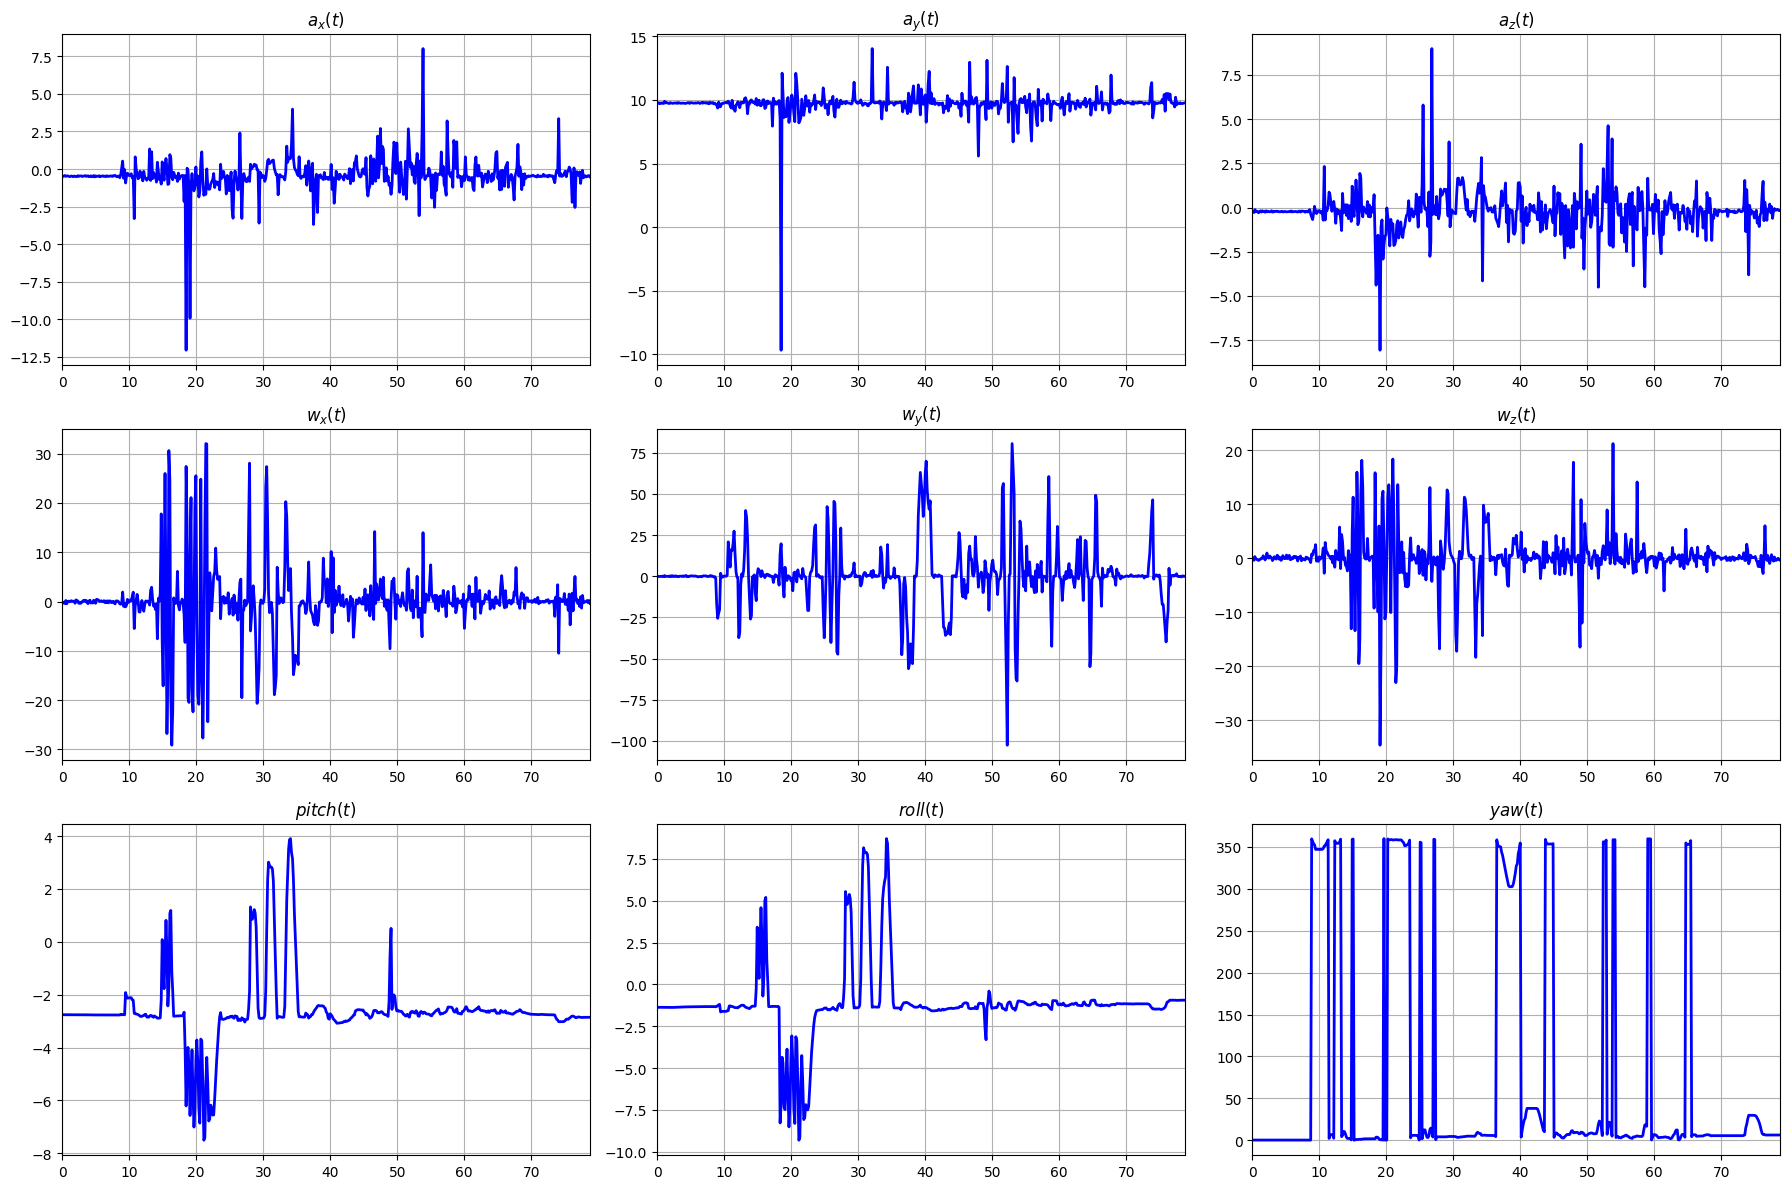

In [8]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

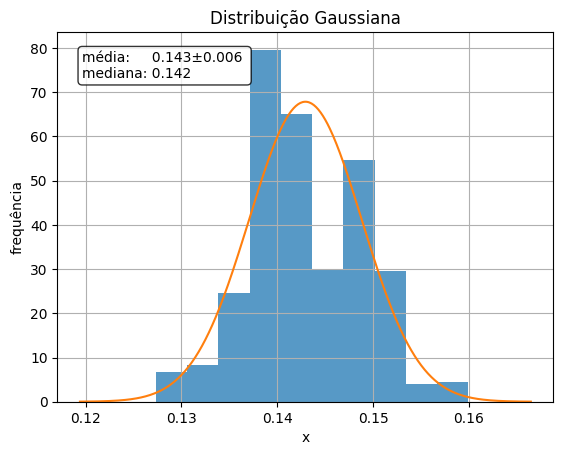

In [9]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time)

In [10]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,az,ay,roll,ax,wz,wx,yaw,tmp,wy,pitch
0,0.0,-0.232447,9.756528,-1.378,-0.507033,0.01867,-0.15625,0.164,50.9,0.17689,-2.757
1,0.1,-0.232447,9.756528,-1.378,-0.507033,0.01867,-0.15625,0.164,50.9,0.17689,-2.757
2,0.2,-0.237027,9.739023,-1.374,-0.492765,0.03994,-0.32461,0.160,50.7,-0.17541,-2.757
3,0.3,-0.284010,9.782035,-1.367,-0.463050,-0.39651,-0.11809,0.157,50.8,-0.06757,-2.757
4,0.4,-0.284010,9.782035,-1.367,-0.463050,-0.39651,-0.11809,0.157,50.8,-0.06757,-2.757
...,...,...,...,...,...,...,...,...,...,...,...
784,78.4,-0.106363,9.714683,-0.944,-0.507288,-0.17441,0.21617,6.186,51.3,0.17442,-2.855
785,78.5,-0.124584,9.738641,-0.945,-0.439250,-0.02421,-0.24364,6.185,51.6,0.24222,-2.857
786,78.6,-0.124584,9.738641,-0.945,-0.439250,-0.02421,-0.24364,6.185,51.6,0.24222,-2.857
787,78.7,-0.176843,9.770052,-0.945,-0.440152,-0.29712,0.20238,6.185,51.4,-0.12095,-2.855


# FILTRANDO POR VARIAVEL

In [11]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

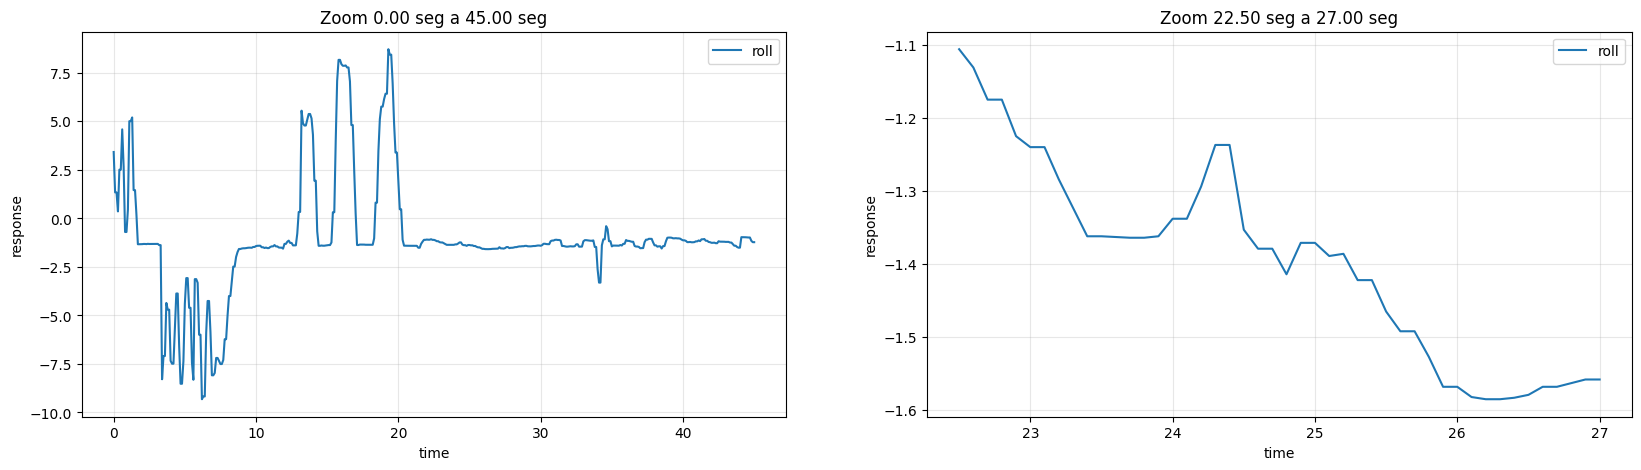

In [12]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [13]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col != 'time'})
df

,time,target_az,target_ay,target_roll,target_ax,target_wz,target_wx,target_yaw,target_tmp,target_wy,target_pitch
150,0.0,1.205541,9.586854,3.421,0.474799,4.87840,-8.22939,359.111,50.7,0.88466,0.083
151,0.1,-0.236860,9.903657,1.339,-0.288051,11.28265,-17.09763,359.416,50.9,4.62676,-1.180
152,0.2,-0.236860,9.903657,1.339,-0.288051,11.28265,-17.09763,359.416,50.9,4.62676,-1.180
153,0.3,-0.504032,9.983356,0.360,-0.744374,-3.59763,3.56802,0.000,50.9,3.70354,-1.773
154,0.4,0.396885,9.572291,2.509,0.237782,-13.43077,25.98087,0.547,50.7,2.58759,-0.436
...,...,...,...,...,...,...,...,...,...,...,...
596,44.6,-0.091300,9.671671,-0.984,-1.175170,0.04832,0.23381,0.249,51.4,11.81421,-2.728
597,44.7,-0.091300,9.671671,-0.984,-1.175170,0.04832,0.23381,0.249,51.4,11.81421,-2.728
598,44.8,0.178814,9.624884,-1.153,-0.736568,0.34637,-1.07239,3.160,51.2,30.27790,-2.630
599,44.9,-1.478362,9.656461,-1.225,-0.468532,0.16277,1.52296,6.285,51.2,12.83723,-2.618


In [14]:
os.makedirs(f'output', exist_ok=True)
INFO = {}

with open('output/info.json', 'w') as file:
    file.write(json.dumps(INFO, indent=4))

df.to_csv('output/data.csv', index=None)